<a href="https://colab.research.google.com/github/HamzaLghali/IrisDLProject_GC/blob/main/simple_NeuralNetwork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [41]:
# Create a Model Class that inherits nn.Module (base class for all neural networks)
class Model(nn.Module):
  # Input layer (4 features of the flower) -->
  # Hidden Layer1 (number of neurons) -->
  # H2 (n) -->
  # output (3 classes of iris flowers)
  def __init__(self, in_features=4, h1=8, h2=9, out_features=3):
    super().__init__() # instantiate our nn.Module
    # fc - fully connected (from, to)
    self.fc1 = nn.Linear(in_features, h1)
    self.fc2 = nn.Linear(h1, h2)
    self.out = nn.Linear(h2, out_features)

  def forward(self, x):
    # Start with layer 1
    x = F.relu(self.fc1(x))
    # Move to layer 2
    x = F.relu(self.fc2(x))
    # Push it to the output
    x = self.out(x)

    return x

In [42]:
# pick a manual seed for randomization
torch.manual_seed(41)

# create an instance of model
model = Model()

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [44]:
url = 'https://gist.githubusercontent.com/netj/8836201/raw/6f9306ad21398ea43cba4f7d537619d0e07d5ae3/iris.csv'

my_df = pd.read_csv(url )

In [45]:
my_df

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica


In [46]:
my_df['variety'] = my_df['variety'].replace('Setosa', 0.0)
my_df['variety'] = my_df['variety'].replace('Versicolor', 1.0)
my_df['variety'] = my_df['variety'].replace('Virginica', 2.0)
my_df

/tmp/ipykernel_1471/594152360.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  my_df['variety'] = my_df['variety'].replace('Virginica', 2.0)


,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


In [47]:
#train test split set x,y

X= my_df.drop('variety', axis=1)
y= my_df['variety']

In [48]:
X = X.values
y = y.values

In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=41)

In [50]:
#convert X features to float tensors
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

In [51]:
#convert y features to long tensors

y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [52]:
# set criterion of model to measure the error

criterion = nn.CrossEntropyLoss()

# choose Adam oprimize, lr = learning rate (if error go down after bunch of itt)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [53]:
print(model.parameters)

<bound method Module.parameters of Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)>


In [54]:
# Train model
# Epoch? (one run through all the training data in network) -> kinda arbitrary
epochs = 100
losses = []
for i in range(epochs):
  # Go forward and get a prediction
  y_pred = model.forward(X_train) # Get predicted results

  # Measure the loss (error) -> it will be high
  loss = criterion(y_pred, y_train) # predicted values vs the y_train

  # Keep track of our losses
  losses.append(loss.detach().numpy())

  # print every 10 epoch
  if i % 10 == 0:
    print(f'Epoch: {i} and loss: {loss}')

  # Do some backpropagation -> take the error rate of forward propagation and feed it back
  # through the network to fine tune the weights
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

Epoch: 0 and loss: 1.125203251838684
Epoch: 10 and loss: 1.0097211599349976
Epoch: 20 and loss: 0.8162347674369812
Epoch: 30 and loss: 0.585993230342865
Epoch: 40 and loss: 0.4003389775753021
Epoch: 50 and loss: 0.26794716715812683
Epoch: 60 and loss: 0.1796349585056305
Epoch: 70 and loss: 0.12165623158216476
Epoch: 80 and loss: 0.0860651507973671
Epoch: 90 and loss: 0.06522614508867264


Text(0.5, 0, 'epoch')

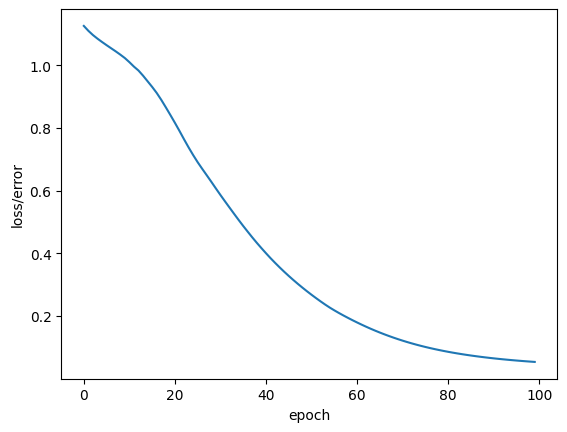

In [55]:
# Graph it out
plt.plot(range(epochs), losses)
plt.ylabel('loss/error')
plt.xlabel('epoch')

In [56]:
# Evaluate Model on Test Data Set (validate model on test set)
# torch.no_grad() -> no gradient -> we check (do not train) how model works
with torch.no_grad(): # basically turn off backpropagation
  y_eval = model.forward(X_test) # X_test are features from our test set, y_eval will be predictions
  loss = criterion(y_eval, y_test) # find the loss/error

In [57]:
loss

tensor(0.1315)

In [58]:
correct = 0
with torch.no_grad():
  for i, data in enumerate(X_test):
    y_val = model.forward(data)

    if y_test[i] == 0:
      x = 'Setosa'
    elif y_test[i] == 1:
      x = 'Versicolor'
    else:
      x = 'Virginica'

    # Will tell us what type of flower class our network think it is
    print(f'{i+1}.) {str(y_val)} \t {x} \t {y_val.argmax().item()}')

    # Correct or not
    if y_val.argmax().item() == y_test[i]:
      correct += 1

  print(f'We got {correct} correct!')

1.) tensor([-5.8771,  4.4629,  6.5155]) 	 Virginica 	 2
2.) tensor([-7.5451,  4.1668,  9.7293]) 	 Virginica 	 2
3.) tensor([-8.4517,  5.1275, 10.2015]) 	 Virginica 	 2
4.) tensor([-4.3411,  5.6280,  2.5636]) 	 Versicolor 	 1
5.) tensor([-7.1838,  4.8757,  8.3023]) 	 Virginica 	 2
6.) tensor([-3.3940,  5.3421,  1.2802]) 	 Versicolor 	 1
7.) tensor([-5.9240,  4.9826,  6.0025]) 	 Virginica 	 2
8.) tensor([-4.2895,  5.7016,  2.3920]) 	 Versicolor 	 1
9.) tensor([-6.5369,  4.9261,  7.1291]) 	 Virginica 	 2
10.) tensor([-8.0526,  4.4129, 10.3325]) 	 Virginica 	 2
11.) tensor([-5.6775,  4.9505,  5.6248]) 	 Virginica 	 2
12.) tensor([ 4.5748, -2.2579, -2.8925]) 	 Setosa 	 0
13.) tensor([ 4.2646, -2.0055, -2.7342]) 	 Setosa 	 0
14.) tensor([-2.1081,  4.0482,  0.5803]) 	 Versicolor 	 1
15.) tensor([ 3.4608, -1.2147, -2.3488]) 	 Setosa 	 0
16.) tensor([-5.4739,  5.1174,  5.0966]) 	 Virginica 	 1
17.) tensor([ 4.0637, -1.8045, -2.6504]) 	 Setosa 	 0
18.) tensor([-5.8090,  4.6057,  6.2494]) 	 Versi

In [59]:
# new data points
new_iris = torch.tensor([4.7, 3.2, 1.3, 0.2])
# it's kinda like test set == unseen new data

In [60]:
with torch.no_grad():
  # model(...) == model.forward(...)
  # the first one is better
  if model(new_iris).argmax().item() == 0:
    x = 'Setosa'
  elif model(new_iris).argmax().item() == 1:
    x = 'Versicolor'
  else:
    x = 'Virginica'
  print(f'{model(new_iris)} -> {x}')

tensor([ 4.5445, -2.2478, -2.8698]) -> Setosa


In [61]:
newer_iris = torch.tensor([5.9, 3.0, 5.1, 1.8])

In [62]:
with torch.no_grad():
  if model(newer_iris).argmax().item() == 0:
    x = 'Setosa'
  elif model(newer_iris).argmax().item() == 1:
    x = 'Versicolor'
  else:
    x = 'Virginica'
  print(f'{model(newer_iris)} -> {x}') # it's virginica, 149 from data set

tensor([-5.9960,  4.5080,  6.6831]) -> Virginica


In [63]:
# save our NN model
torch.save(model.state_dict(), 'my_iris_model.pt') # saving on google colab unit

In [64]:
# load saved model
new_model = Model()
new_model.load_state_dict(torch.load('my_iris_model.pt'))


<All keys matched successfully>

In [65]:
new_model.eval()

Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)